# 01 — Encrypted-flow data exploration

Exploratory analysis of the chronological CESNET-QUIC22 splits using metadata only—never packet payloads.

In [1]:
from pathlib import Path
import ast
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed" / "datazoo_smoke"
names = ["train", "calibration", "test_known", "test_unknown"]
paths = {name: DATA / f"{name}.csv" for name in names}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing: raise FileNotFoundError("Prepare the dataset first. Missing: " + ", ".join(missing))
frames = {name: pd.read_csv(path) for name, path in paths.items()}
pd.DataFrame({"split": names, "flows": [len(frames[name]) for name in names]})

,split,flows
0,train,5000
1,calibration,1000
2,test_known,1000
3,test_unknown,1000


## Split sizes and application balance

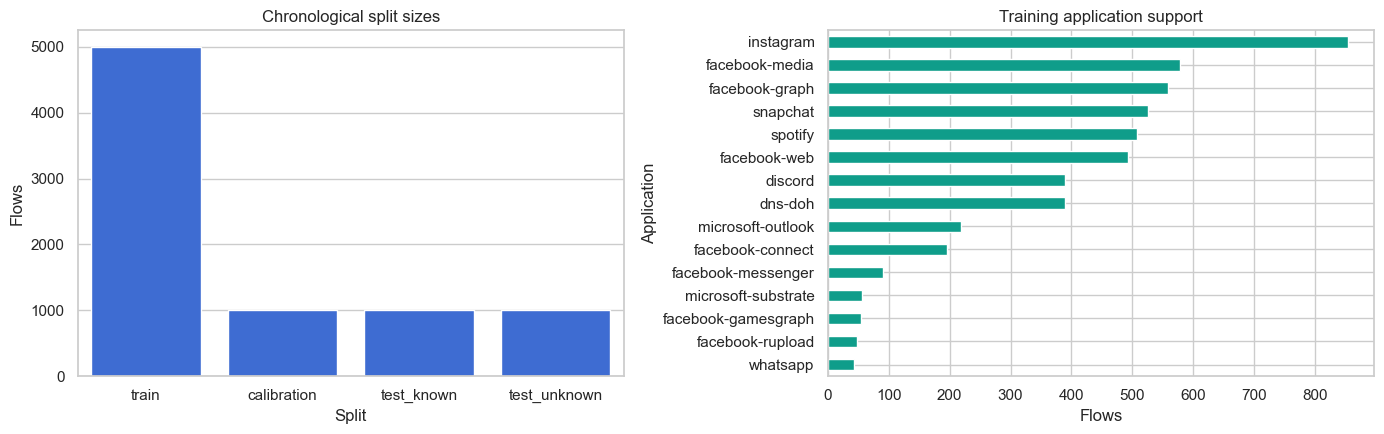

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sizes = pd.Series({name: len(frame) for name, frame in frames.items()})
sns.barplot(x=sizes.index, y=sizes.values, color="#2563EB", ax=axes[0])
axes[0].set(title="Chronological split sizes", xlabel="Split", ylabel="Flows")
frames["train"]["label"].value_counts().head(15).sort_values().plot.barh(color="#0F9D8A", ax=axes[1])
axes[1].set(title="Training application support", xlabel="Flows", ylabel="Application")
plt.tight_layout(); plt.show()

## Flow-length and byte-volume distributions

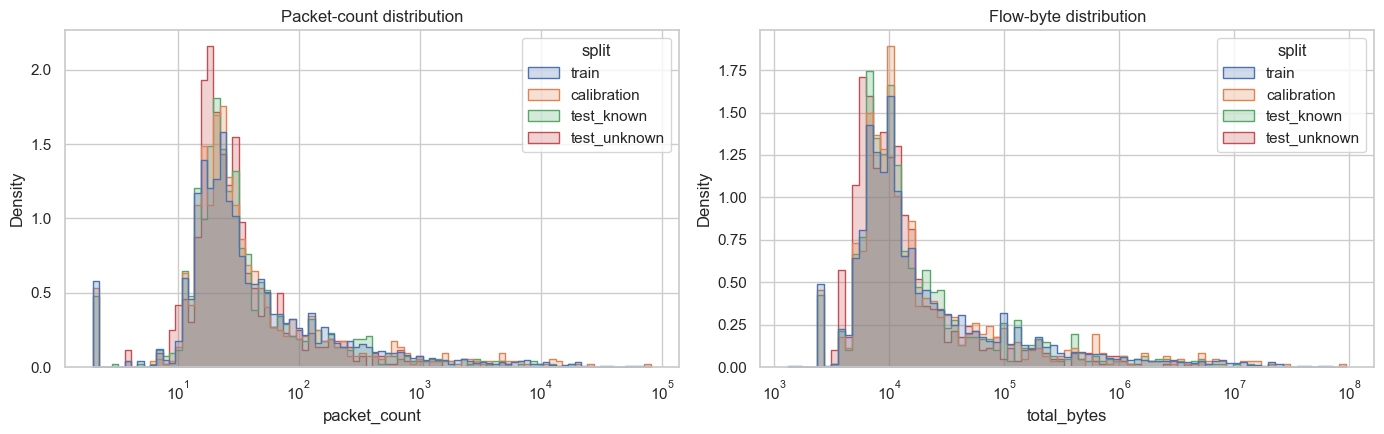

In [3]:
combined = pd.concat([frame.assign(split=name) for name, frame in frames.items()], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=combined, x="packet_count", hue="split", element="step", stat="density", common_norm=False, log_scale=(True, False), ax=axes[0])
sns.histplot(data=combined, x="total_bytes", hue="split", element="step", stat="density", common_norm=False, log_scale=(True, False), ax=axes[1])
axes[0].set_title("Packet-count distribution"); axes[1].set_title("Flow-byte distribution")
plt.tight_layout(); plt.show()

## Behavioral relationship and chronological activity

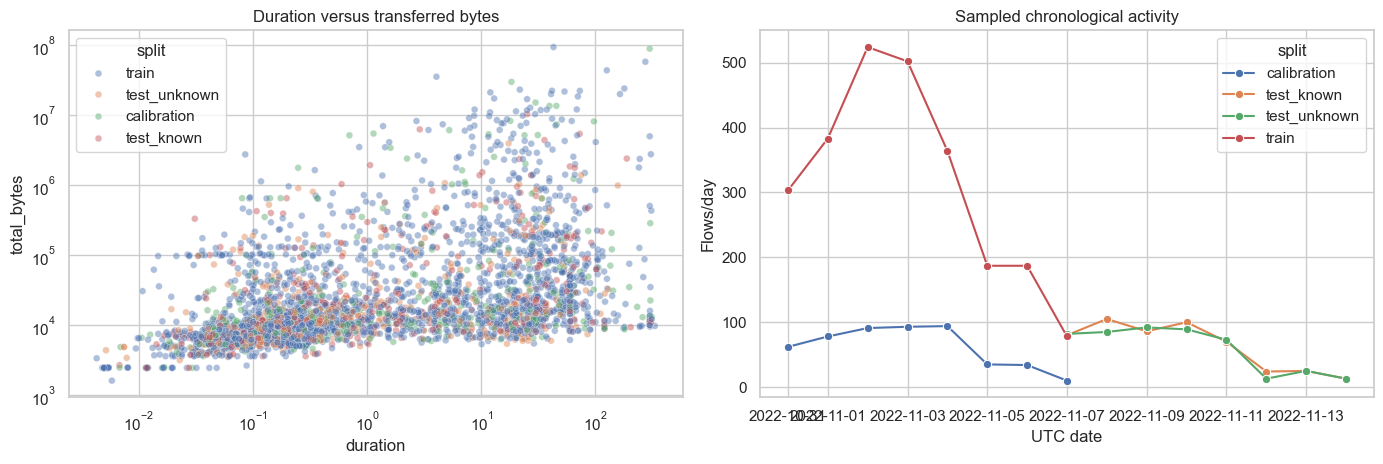

In [4]:
sample = combined.sample(min(4000, len(combined)), random_state=42).copy()
sample["start_datetime"] = pd.to_datetime(sample["start_time"], unit="s", utc=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.scatterplot(data=sample, x="duration", y="total_bytes", hue="split", alpha=.45, s=24, ax=axes[0])
axes[0].set(xscale="log", yscale="log", title="Duration versus transferred bytes")
activity = sample.set_index("start_datetime").groupby("split").resample("1D").size().rename("flows").reset_index()
sns.lineplot(data=activity, x="start_datetime", y="flows", hue="split", marker="o", ax=axes[1])
axes[1].set(title="Sampled chronological activity", xlabel="UTC date", ylabel="Flows/day")
plt.tight_layout(); plt.show()

## Early packet-size profile

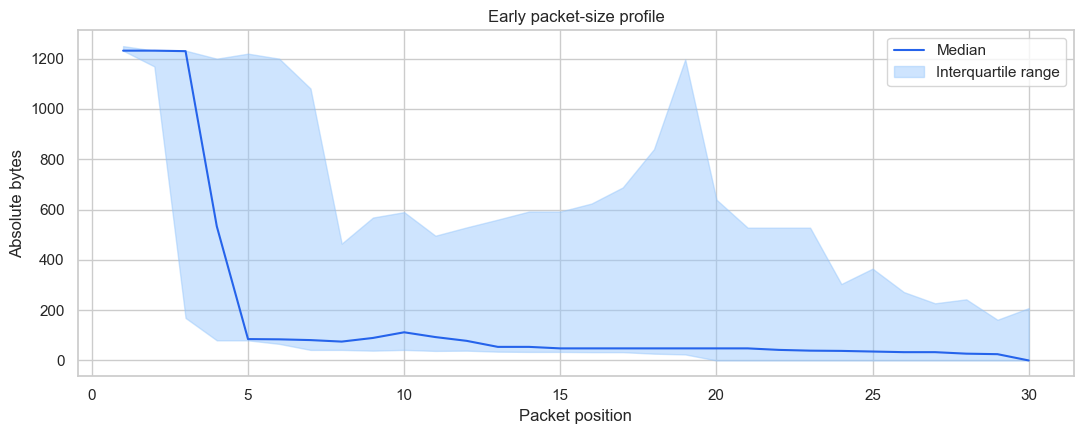

In [5]:
parse = lambda value: ast.literal_eval(value) if isinstance(value, str) else value
profile = pd.DataFrame(frames["train"]["packet_sizes"].head(2000).map(parse).tolist()).iloc[:, :32].abs()
x = range(1, len(profile.columns) + 1); median = profile.median(); q25 = profile.quantile(.25); q75 = profile.quantile(.75)
plt.figure(figsize=(11, 4.5)); plt.plot(x, median, color="#2563EB", label="Median")
plt.fill_between(x, q25, q75, color="#93C5FD", alpha=.45, label="Interquartile range")
plt.xlabel("Packet position"); plt.ylabel("Absolute bytes"); plt.title("Early packet-size profile")
plt.legend(); plt.tight_layout(); plt.show()